# Chapter 5: Classification
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
library(discrim)
library(ggpubr)
library(mgcv)
library(patchwork)
library(rpart)
library(tidymodels)
library(tidyverse)

set.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
DATA_DIR <- '../../data'


Loading required package: parsnip



Loading required package: ggplot2



Loading required package: nlme



This is mgcv 1.9-4. For overview type '?mgcv'.



── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────── tidymodels 1.4.1 ──



✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tailor       0.1.0 
✔ dplyr        1.2.1      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ purrr        1.2.2      ✔ workflowsets 1.1.1 
✔ recipes      1.3.2      ✔ yardstick    1.4.0 



── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ dplyr::collapse()   masks nlme::collapse()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
✖ dials::prune()      masks rpart::prune()
✖ dials::smoothness() masks discrim::smoothness()
✖ recipes::step()     masks stats::step()



── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ readr     2.2.0     


── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ dplyr::collapse()   masks nlme::collapse()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ stringr::fixed()    masks recipes::fixed()
✖ dplyr::lag()        masks stats::lag()
✖ readr::spec()       masks yardstick::spec()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Classification
### Naive Bayes
#### The Naive Solution

In [1]:
loan_data <- read_csv(file.path(DATA_DIR, "loan_data.csv.gz"), show_col_types = FALSE) %>%
  dplyr::select(-c(index, status)) %>%
  mutate(
    across(where(is.character), as.factor),
    outcome = factor(outcome, levels = c("paid off", "default")),
  )
naive_model <- naive_Bayes() %>%
  fit(outcome ~ purpose_ + home_ + emp_len_, loan_data)

naive_model %>%
  extract_fit_engine() %>%
  pluck("tables")

$purpose_
          var
grouping   credit_card debt_consolidation home_improvement major_purchase
  paid off  0.18759649         0.55215915       0.07150104     0.05359270
  default   0.15151515         0.57571347       0.05981209     0.03727229
          var
grouping      medical      other small_business
  paid off 0.01424728 0.09990737     0.02099599
  default  0.01433549 0.11561025     0.04574126

$home_
          var
grouping    MORTGAGE       OWN      RENT
  paid off 0.4894800 0.0808963 0.4296237
  default  0.4313440 0.0832782 0.4853778

$emp_len_
          var
grouping     < 1 Year   > 1 Year
  paid off 0.03105289 0.96894711
  default  0.04728508 0.95271492


In [1]:
new_loan <- loan_data[147, c("purpose_", "home_", "emp_len_")]
row.names(new_loan) <- NULL
new_loan

purpose_,home_,emp_len_
<fct>,<fct>,<fct>
small_business,MORTGAGE,> 1 Year


In [1]:
predict(naive_model, new_loan)

.pred_class
<fct>
default


In [1]:
predict(naive_model, new_loan, type = "prob")

.pred_paid off,.pred_default
<dbl>,<dbl>
0.3463013,0.6536987


#### Numeric Predictor Variables

In [1]:
less_naive <- naive_Bayes() %>%
  set_args(usekernel = FALSE) %>%
  fit(outcome ~ borrower_score + payment_inc_ratio +
      purpose_ + home_ + emp_len_, loan_data)

(naive_model %>%
    extract_fit_engine() %>%
    pluck("tables"))[1:2]

$purpose_
          var
grouping   credit_card debt_consolidation home_improvement major_purchase
  paid off  0.18759649         0.55215915       0.07150104     0.05359270
  default   0.15151515         0.57571347       0.05981209     0.03727229
          var
grouping      medical      other small_business
  paid off 0.01424728 0.09990737     0.02099599
  default  0.01433549 0.11561025     0.04574126

$home_
          var
grouping    MORTGAGE       OWN      RENT
  paid off 0.4894800 0.0808963 0.4296237
  default  0.4313440 0.0832782 0.4853778


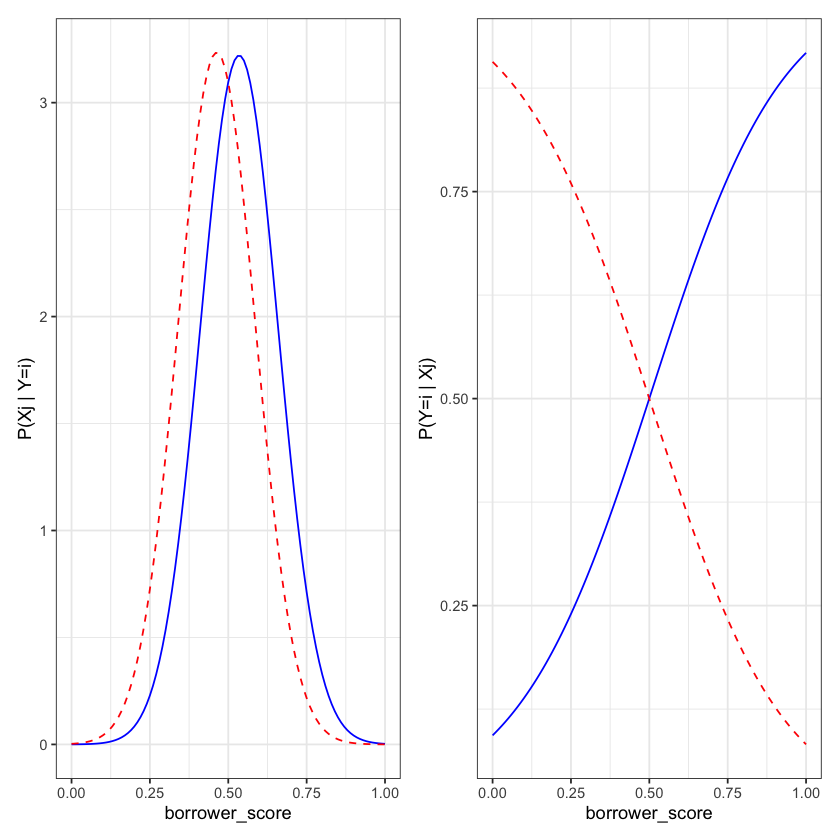

In [1]:
p_paid <- sum(loan_data$outcome == "default") / nrow(loan_data)
p_default <- sum(loan_data$outcome == "paid off") / nrow(loan_data)
p_bs_paid <- function(x, stats) dnorm(x, mean = stats[1, 1], sd = stats[1, 2])
p_bs_default <- function(x, stats) dnorm(x, mean = stats[2, 1], sd = stats[2, 2])
p_paid_bs <- function(x, stats) {
  return(p_paid * p_bs_paid(x, stats) /
      (p_paid * p_bs_paid(x, stats) + p_default * p_bs_default(x, stats)))
}
p_default_bs <- function(x, stats) {
  return(p_default * p_bs_default(x, stats) /
      (p_paid * p_bs_paid(x, stats) + p_default * p_bs_default(x, stats)))
}

stats <- less_naive %>%
  extract_fit_engine() %>%
  pluck("tables", "borrower_score")
g1 <- ggplot(data.frame(borrower_score = c(0, 1)), aes(x = borrower_score)) +
  stat_function(fun = p_bs_paid, color = "blue", linetype = 1,
    args = list(stats = stats)) +
  stat_function(fun = p_bs_default, color = "red", linetype = 2,
    args = list(stats = stats)) +
  labs(y = "P(Xj | Y=i)") + theme_bw()
g2 <- ggplot(data.frame(borrower_score = c(0, 1)), aes(x = borrower_score)) +
  stat_function(fun = p_paid_bs, color = "blue", linetype = 1,
    args = list(stats = stats)) +
  stat_function(fun = p_default_bs, color = "red", linetype = 2,
    args = list(stats = stats)) +
  labs(y = "P(Y=i | Xj)") + theme_bw()
g <- wrap_plots(g1, g2)
g

### Discriminant Analysis
#### A Simple Example

In [1]:
loan3000 <- read_csv(file.path(DATA_DIR, "loan3000.csv"), show_col_types = FALSE) %>%
  mutate(
    outcome = factor(outcome, levels = c("paid off", "default")),
    purpose_ = factor(purpose_)
  )

loan_lda <- discrim_linear() %>%
  fit(outcome ~ borrower_score + payment_inc_ratio, data = loan3000)

loan_lda %>%
  extract_fit_engine() %>%
  pluck("scaling")

,LD1
borrower_score,-7.17583880
payment_inc_ratio,0.09967559


In [1]:
lda_pred <- augment(loan_lda, new_data = loan3000)
head(lda_pred %>% select(.pred_class, .pred_default, `.pred_paid off`))

.pred_class,.pred_default,.pred_paid off
<fct>,<dbl>,<dbl>
default,0.5535437,0.4464563
default,0.5589534,0.4410466
paid off,0.2726962,0.7273038
default,0.5062538,0.4937462
default,0.6099525,0.3900475
paid off,0.4107406,0.5892594


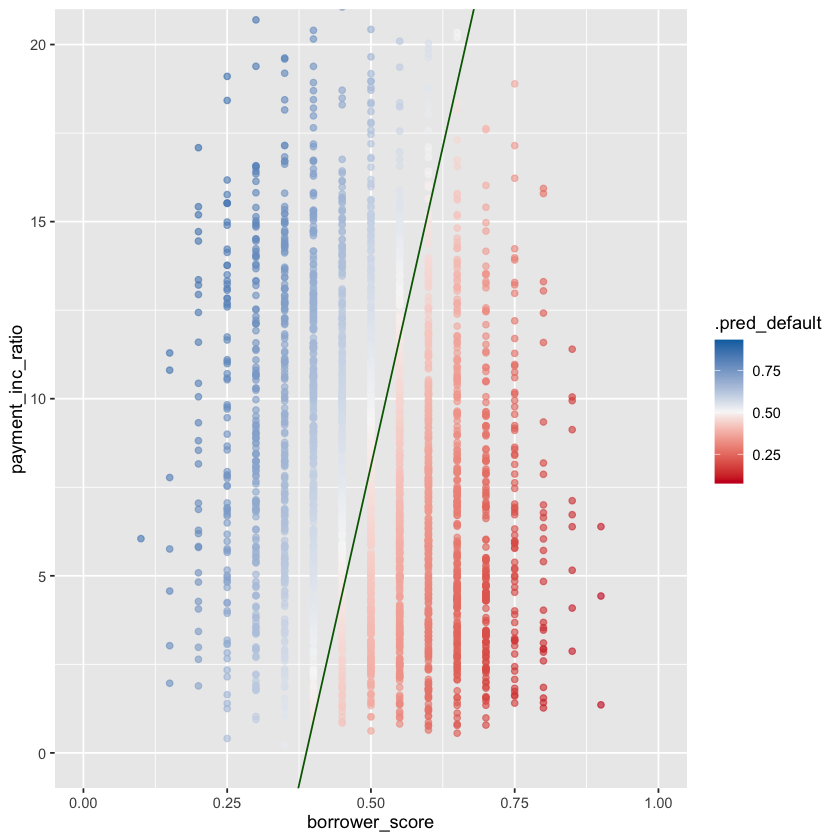

In [1]:
loan_fit_engine <- loan_lda %>% extract_fit_engine()
center <- 0.5 * (loan_fit_engine$mean[1, ] + loan_fit_engine$mean[2, ])
slope <- -loan_fit_engine$scaling[1] / loan_fit_engine$scaling[2]
intercept <- center[2] - center[1] * slope

ggplot(data = lda_pred,
  aes(x = borrower_score, y = payment_inc_ratio, color = .pred_default)) +
  geom_point(alpha = 0.6) +
  scale_color_gradientn(colors = c("#ca0020", "#f7f7f7", "#0571b0")) +
  coord_cartesian(xlim = c(0, 1), ylim = c(0, 20)) +
  geom_abline(slope = slope, intercept = intercept, color = "darkgreen")

### Logistic Regression
#### Logistic Regression and the GLM

In [1]:
logistic_model <- logistic_reg(mode = "classification") %>%
  fit(outcome ~ payment_inc_ratio + purpose_ +
      home_ + emp_len_ + borrower_score, loan_data)
logistic_model

parsnip model object


Call:  stats::glm(formula = outcome ~ payment_inc_ratio + purpose_ + 
    home_ + emp_len_ + borrower_score, family = stats::binomial, 
    data = data)

Coefficients:
               (Intercept)           payment_inc_ratio  
                   1.63809                     0.07974  
purpose_debt_consolidation    purpose_home_improvement  
                   0.24937                     0.40774  
    purpose_major_purchase             purpose_medical  
                   0.22963                     0.51048  
             purpose_other      purpose_small_business  
                   0.62066                     1.21526  
                  home_OWN                   home_RENT  
                   0.04833                     0.15732  
          emp_len_> 1 Year              borrower_score  
                  -0.35673                    -4.61264  

Degrees of Freedom: 45341 Total (i.e. Null);  45330 Residual
Null Deviance:	    62860 
Residual Deviance: 57510 	AIC: 57540

#### Predicted Values from Logistic Regression

In [1]:
pred <- predict(logistic_model, new_data = loan_data, type = "raw")
summary(pred)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-2.704774 -0.518825 -0.008539  0.002564  0.505061  3.509606 

In [1]:
prob <- 1 / (1 + exp(-pred))
summary(prob)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.06269 0.37313 0.49787 0.50000 0.62365 0.97096 

In [1]:
prob <- predict(logistic_model, new_data = loan_data, type = "prob")
summary(prob$.pred_default)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.06269 0.37313 0.49787 0.50000 0.62365 0.97096 

#### Assessing the Model

In [1]:
logistic_model %>%
  extract_fit_engine() %>%
  summary()


Call:
stats::glm(formula = outcome ~ payment_inc_ratio + purpose_ + 
    home_ + emp_len_ + borrower_score, family = stats::binomial, 
    data = data)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 1.638092   0.073708  22.224  < 2e-16 ***
payment_inc_ratio           0.079737   0.002487  32.058  < 2e-16 ***
purpose_debt_consolidation  0.249373   0.027615   9.030  < 2e-16 ***
purpose_home_improvement    0.407743   0.046615   8.747  < 2e-16 ***
purpose_major_purchase      0.229628   0.053683   4.277 1.89e-05 ***
purpose_medical             0.510479   0.086780   5.882 4.04e-09 ***
purpose_other               0.620663   0.039436  15.738  < 2e-16 ***
purpose_small_business      1.215261   0.063320  19.192  < 2e-16 ***
home_OWN                    0.048330   0.038036   1.271    0.204    
home_RENT                   0.157320   0.021203   7.420 1.17e-13 ***
emp_len_> 1 Year           -0.356731   0.052622  -6.779 1.21e-11 ***
borr

In [1]:
gam_formula <- outcome ~ s(payment_inc_ratio) + purpose_ +
  home_ + emp_len_ + s(borrower_score)
logistic_gam <- gen_additive_mod(mode = "classification") %>%
  fit(gam_formula, data = loan_data)

##### Analysis of residuals

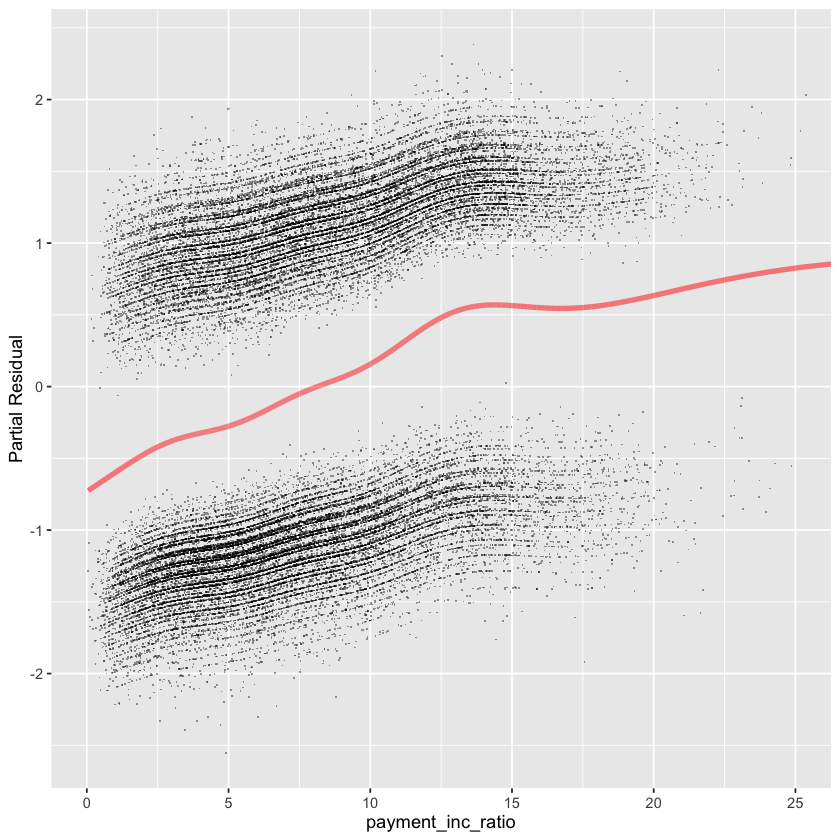

In [1]:
terms <- predict(logistic_gam %>% extract_fit_engine(), type = "terms")
partial_resid <- resid(logistic_gam %>% extract_fit_engine()) + terms
df <- data.frame(payment_inc_ratio = loan_data[, "payment_inc_ratio"],
  terms = terms[, "s(payment_inc_ratio)"],
  partial_resid = partial_resid[, "s(payment_inc_ratio)"])
ggplot(df, aes(x = payment_inc_ratio, y = partial_resid, solid = FALSE)) +
  geom_point(shape = 46, alpha = 0.4) +
  geom_line(aes(x = payment_inc_ratio, y = terms),
    color = "red", alpha = 0.5, linewidth = 1.5) +
  labs(y = "Partial Residual") +
  coord_cartesian(xlim = c(0, 25))

### Evaluating Classification Models
####  Confusion Matrix

In [1]:
predictions <- augment(logistic_gam, loan_data)
pred_y <- as.numeric(predictions$.pred_class == "default")
true_y <- as.numeric(predictions$outcome == "default")
true_pos <- (true_y == 1) & (pred_y == 1)
true_neg <- (true_y == 0) & (pred_y == 0)
false_pos <- (true_y == 0) & (pred_y == 1)
false_neg <- (true_y == 1) & (pred_y == 0)
conf_mat <- matrix(
  c(sum(true_neg), sum(false_pos),
    sum(false_neg), sum(true_pos)), 2, 2)
rownames(conf_mat) <- c("Yhat = 0", "Yhat = 1")
colnames(conf_mat) <- c("Y = 0", "Y = 1")
conf_mat

,Y = 0,Y = 1
Yhat = 0,14620,8378
Yhat = 1,8051,14293


In [1]:
conf_mat(predictions, truth = outcome, estimate = .pred_class)

          Truth
Prediction paid off default
  paid off    14620    8378
  default      8051   14293

#### Precision, Recall, and Specificity

In [1]:
bind_rows(
  precision(predictions, truth = outcome, estimate = .pred_class),
  recall(predictions, truth = outcome, estimate = .pred_class),
  specificity(predictions, truth = outcome, estimate = .pred_class),
) %>% select(-.estimator)

.metric,.estimate
<chr>,<dbl>
precision,0.6357075
recall,0.6448767
specificity,0.6304530


#### ROC Curve

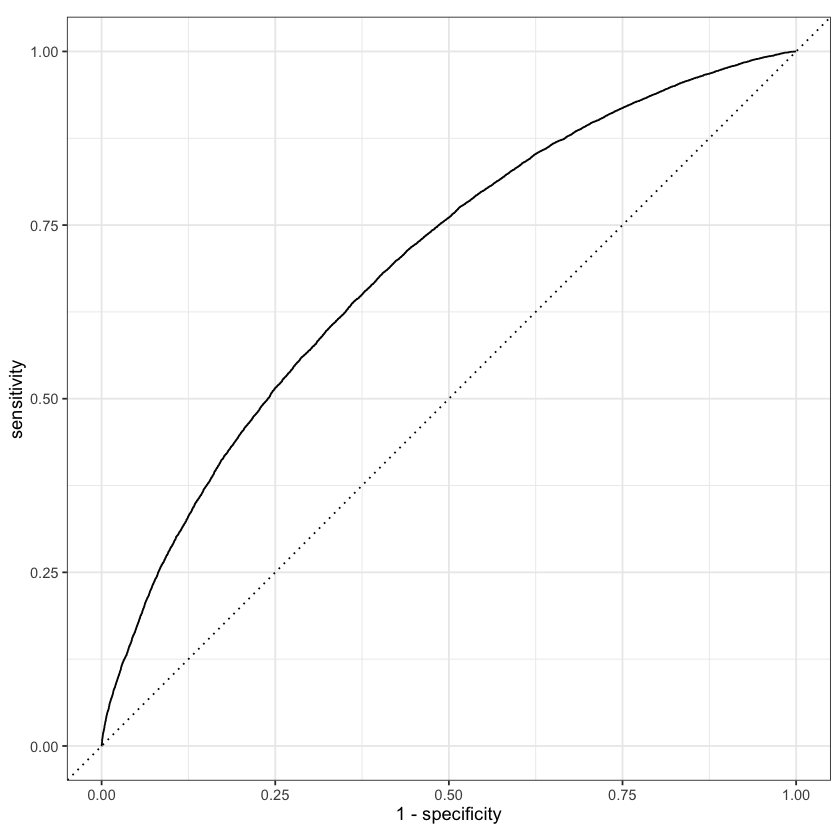

In [1]:
roc_curve(predictions, outcome, .pred_default, event_level = "second") %>%
  autoplot()

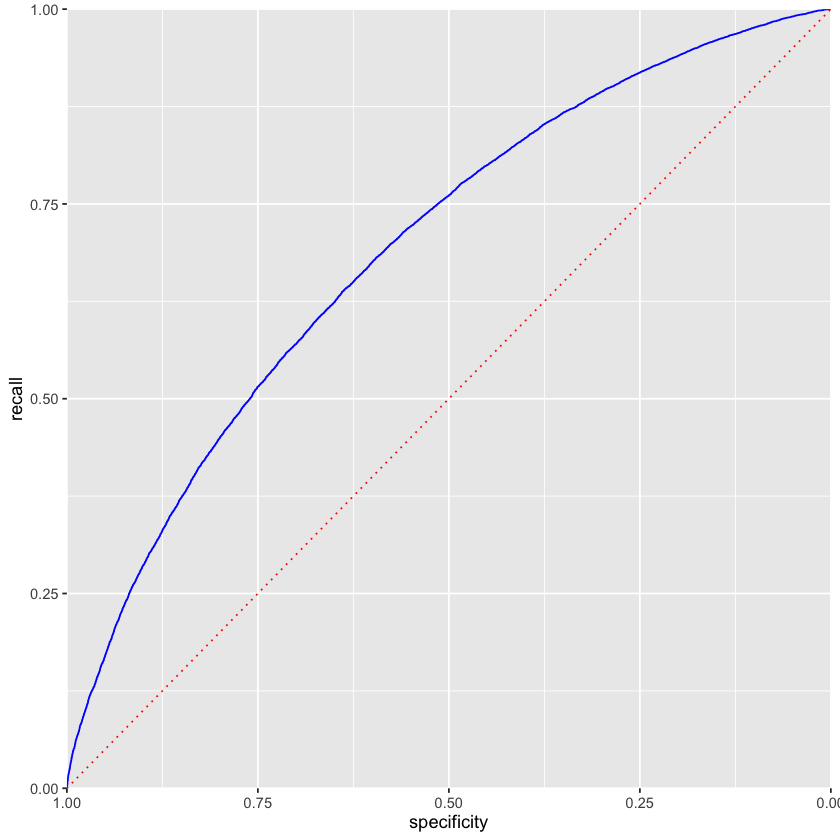

In [1]:
prob <- predict(logistic_gam, new_data = loan_data, type = "prob")
idx <- order(-prob$.pred_default)
recall <- cumsum(true_y[idx] == 1) / sum(true_y == 1)
specificity <- (sum(true_y == 0) - cumsum(true_y[idx] == 0)) / sum(true_y == 0)
roc_df <- data.frame(recall = recall, specificity = specificity)
ggplot(roc_df, aes(x = specificity, y = recall)) +
  geom_line(color = "blue") +
  scale_x_reverse(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0)) +
  geom_line(data = data.frame(x = (0:100) / 100), aes(x = x, y = 1 - x),
    linetype = "dotted", color = "red")

#### AUC

In [1]:
sum(roc_df$recall[-1] * diff(1 - roc_df$specificity))

[1] 0.6926232

### Strategies for Imbalanced Data
#### Undersampling

In [1]:
full_train_set <- read_csv(file.path(DATA_DIR, "full_train_set.csv.gz"), show_col_types = FALSE) %>%
  mutate(
    across(where(is.character), as.factor),
    outcome = factor(outcome, levels = c("paid off", "default")),
  )

mean(full_train_set$outcome == "default")

[1] 0.1889455

In [1]:
full_model <- logistic_reg(mode = "classification") %>%
  fit(outcome ~ payment_inc_ratio + purpose_ +
      home_ + emp_len_ + dti + revol_bal + revol_util,
    full_train_set)
pred <- predict(full_model, new_data = full_train_set)
100 * mean(pred == "default")

[1] 0.3942094

#### Oversampling and Up/Down Weighting

In [1]:
full_train_set <- full_train_set %>%
  mutate(
    weight = ifelse(outcome == "default", 1 / mean(outcome == "default"), 1.0),
    weight = importance_weights(weight))
weighted_model <- workflow() %>%
  add_model(logistic_reg(mode = "classification")) %>%
  add_case_weights(weight) %>%
  add_formula(outcome ~ payment_inc_ratio + purpose_ +
      home_ + emp_len_ + dti + revol_bal + revol_util) %>%
  fit(full_train_set)
pred <- predict(weighted_model, new_data = full_train_set)
100 * mean(pred == "default")

Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”


[1] 57.67208

# Supplementary Material
## Figure 5-2. Graph of the logit function that maps a probability to a scale suitable for a linear model

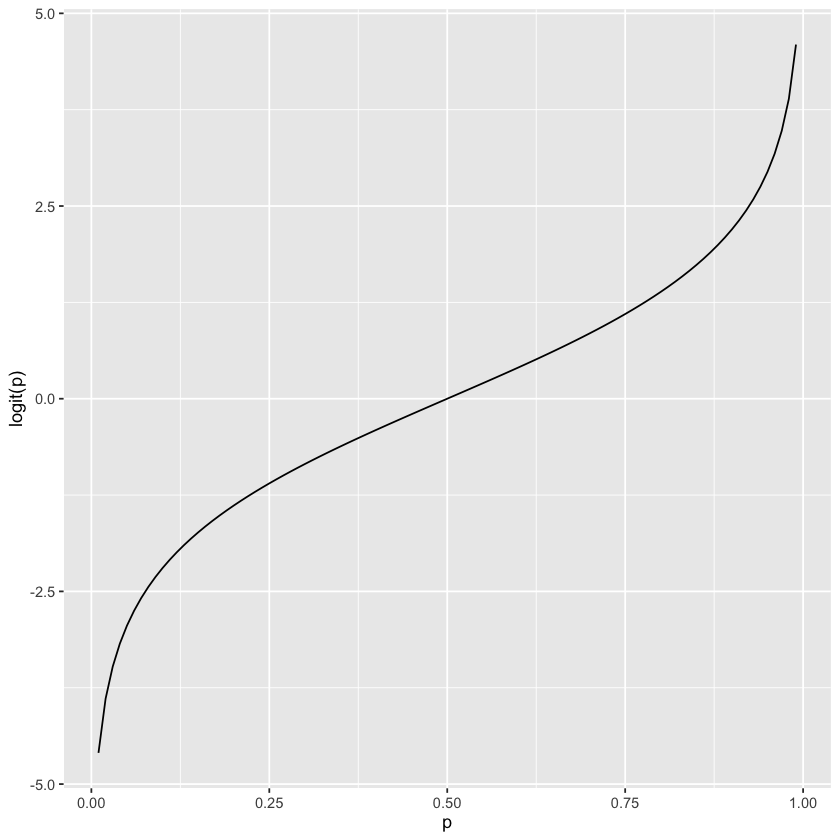

In [1]:
p <- seq(from = 0.01, to = 0.99, by = 0.01)
df <- tibble(
  p = p,
  logit = log(p / (1 - p)),
  odds = p / (1 - p),
)

graph <- ggplot(data = df, aes(x = p, y = logit)) +
  geom_line() +
  labs(x = "p", y = "logit(p)")
graph

## How to control the order of the classes in Python

## Figure 5-3. The relationship between the odds ratio and the log-odds ratio

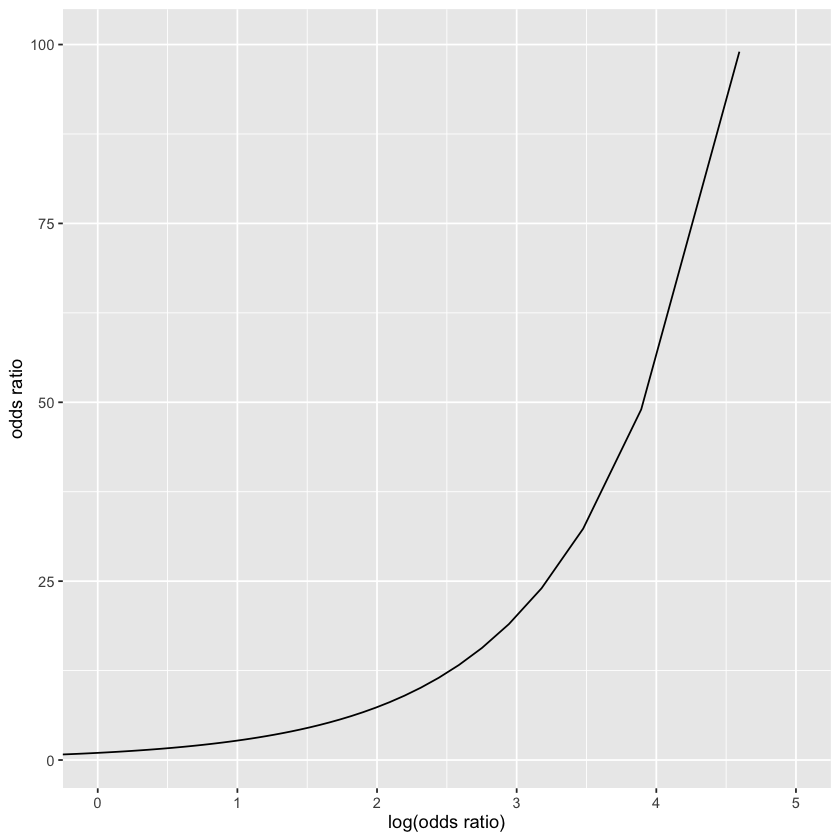

In [1]:
graph <- ggplot(data = df, aes(x = logit, y = odds)) +
  geom_line() +
  labs(x = "log(odds ratio)", y = "odds ratio") +
  coord_cartesian(xlim = c(0, 5), ylim = c(1, 100))
graph

## Figure 5-4. Partial residuals from logistic regression

## Figure 5-7. Area under the ROC curve for the loan data

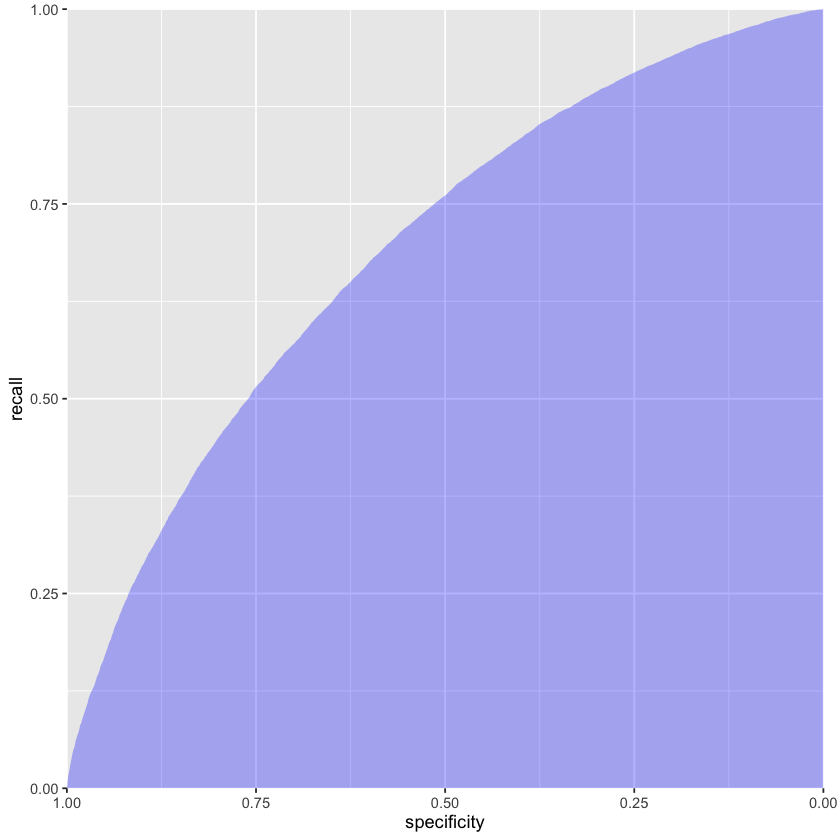

In [1]:
graph <- ggplot(roc_df, aes(specificity)) +
  geom_ribbon(aes(ymin = 0, ymax = recall), fill = "blue", alpha = 0.3) +
  scale_x_reverse(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0)) +
  labs(y = "recall") +
  theme(plot.margin = unit(c(5.5, 10, 5.5, 5.5), "points"))
graph

## SMOTE

## Figure 5-8. Comparison of the classification rules for four different methods

In [1]:
loan_tree <- rpart(outcome ~ borrower_score + payment_inc_ratio,
  data = loan3000, control = rpart.control(cp = 0.005))
loan_tree

lda_pred <- tibble(
  borrower_score = c((0 - intercept) / slope, (20 - intercept) / slope),
  payment_inc_ratio = c(0, 20),
  method = "LDA",
)

tree_pred <- tibble(
  borrower_score = c(0.375, 0.375, 0.475, 0.475, 0.575, 0.575),
  payment_inc_ratio = c(0, 4.426,  4.426, 10.42, 10.42, 20),
  method = "Tree",
)

glm0 <- glm(outcome ~ payment_inc_ratio +  borrower_score,
  data = loan3000, family = "binomial")
y <- seq(from = 0, to = 20, length = 100)
x <- (- glm0$coefficients[1] - glm0$coefficients[2] * y) / glm0$coefficients[3]
glm0_pred <- tibble(
  borrower_score = x,
  payment_inc_ratio = y,
  method = "Logistic",
)

gam1 <- gam(outcome ~ s(payment_inc_ratio) +  s(borrower_score),
  data = loan3000, family = "binomial")
gam_fun <- function(x) {
  newdata <- data.frame(borrower_score = x, payment_inc_ratio = y)
  rss <- sum(predict(gam1, newdata = newdata)^2)
  return(rss)
}
est_x <- nlminb(seq(from = 0.33, to = 0.73, length = 100), gam_fun)
gam1_pred <- tibble(
  borrower_score = est_x$par,
  payment_inc_ratio = y,
  method = "GAM",
)

loan_fits <- bind_rows(
  lda_pred,
  tree_pred,
  glm0_pred,
  gam1_pred,
)

n= 3000 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 3000 1445 paid off (0.5183333 0.4816667)  
   2) borrower_score>=0.575 878  261 paid off (0.7027335 0.2972665) *
   3) borrower_score< 0.575 2122  938 default (0.4420358 0.5579642)  
     6) borrower_score>=0.375 1639  802 default (0.4893228 0.5106772)  
      12) payment_inc_ratio< 10.42265 1157  547 paid off (0.5272256 0.4727744)  
        24) payment_inc_ratio< 4.42601 334  139 paid off (0.5838323 0.4161677) *
        25) payment_inc_ratio>=4.42601 823  408 paid off (0.5042527 0.4957473)  
          50) borrower_score>=0.475 418  190 paid off (0.5454545 0.4545455) *
          51) borrower_score< 0.475 405  187 default (0.4617284 0.5382716) *
      13) payment_inc_ratio>=10.42265 482  192 default (0.3983402 0.6016598) *
     7) borrower_score< 0.375 483  136 default (0.2815735 0.7184265) *

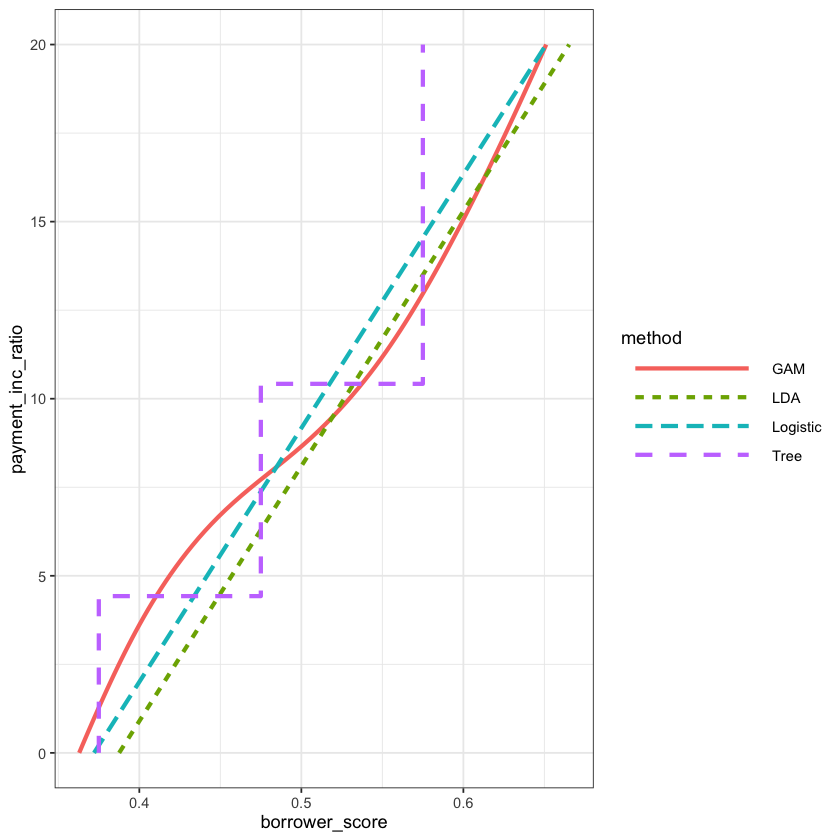

In [1]:
graph <- ggplot(data = loan_fits, aes(x = borrower_score, y = payment_inc_ratio, color = method, linetype = method)) +
  geom_line(linewidth = 1.2) +
  theme_bw() +
  theme(legend.key.width = unit(3, "cm")) +
  guides(linetype = guide_legend(override.aes = list(size = 1)))
graph

# Naive Bayes with numerical features

# print(f"MixedNB Library Accuracy: {accuracy_mixed:.2f}")